Explore the descriptive statistics on any dataset.

--- Dataset Head ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Summary Statistics (Numerical) ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



--- Summary Statistics (Categorical) ---


,species
count,150
unique,3
top,setosa
freq,50



--- Additional Metrics ---
Median: 
sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

Skewness: 
sepal_length    0.314911
sepal_width     0.318966
petal_length   -0.274884
petal_width    -0.102967
dtype: float64


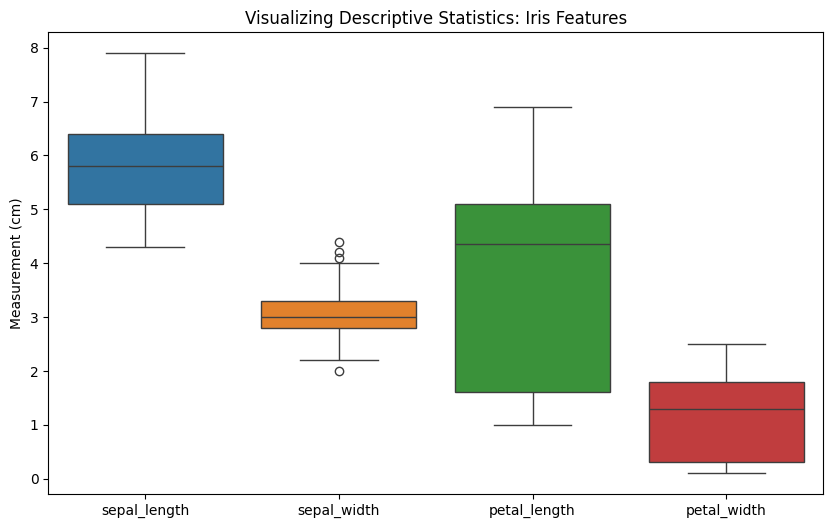

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- DATASET DESCRIPTION ---
# The 'Iris' dataset is a classic "hello world" dataset for data science.
# It contains 150 samples from three species of Iris flowers (Setosa, Virginica, Versicolor).
# Four features were measured from each sample:
# 1. Sepal Length  2. Sepal Width  3. Petal Length  4. Petal Width (all in cm).

# 1. Load the inbuilt dataset directly from Seaborn
df = sns.load_dataset('iris')

# 2. Basic Inspection
# .head() shows the first 5 rows to understand the structure
print("--- Dataset Head ---")
print(df.head())

# 3. Comprehensive Descriptive Statistics
# .describe() by default calculates count, mean, std, and the 5-number summary (min, Q1, Q2, Q3, max)
print("\n--- Summary Statistics (Numerical) ---")
# display() is a Colab/Jupyter function that renders DataFrames as clean HTML tables
display(df.describe())

# By including 'object', we see the frequency, unique counts, and top category for the Species column
print("\n--- Summary Statistics (Categorical) ---")
display(df.describe(include='object'))

# 4. Specific Statistics (Deep Dive)
# We drop 'species' because you cannot calculate math on text strings.
print("\n--- Additional Metrics ---")
# Median: The middle value (50th percentile). Great for checking if data is biased by outliers.
print(f"Median: \n{df.drop(columns='species').median()}\n")
# Skewness: Measures asymmetry.
# 0 = symmetric, >0 = right-skewed (long right tail), <0 = left-skewed (long left tail).
print(f"Skewness: \n{df.drop(columns='species').skew()}")

# 5. Visualization: Boxplot
# Boxplots are the visual representation of df.describe().
# The box represents the Interquartile Range (IQR), and the line inside is the Median.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Visualizing Descriptive Statistics: Iris Features')
plt.ylabel('Measurement (cm)')
plt.show()

Explore the inferential statistics T Test to compare the mean of two variables.

T-Statistic: -10.5210
P-Value: 8.9852e-18

Result: Reject the Null Hypothesis.
Conclusion: There is a statistically significant difference between the means.


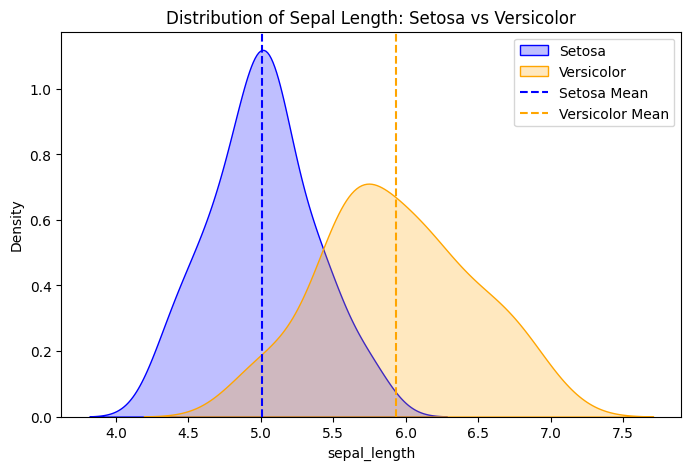

In [3]:
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# --- 1. DATASET PREPARATION ---
# Iris dataset: 150 samples of flowers.
# We want to see if 'Setosa' and 'Versicolor' have significantly different Sepal Lengths.
df = sns.load_dataset('iris')

# Filter the data into two distinct groups
group_a = df[df['species'] == 'setosa']['sepal_length']
group_b = df[df['species'] == 'versicolor']['sepal_length']

# --- 2. THE T-TEST PROCESS ---
# We use an Independent Samples T-Test because the two groups of flowers are separate.
# Null Hypothesis (H0): There is NO difference in mean sepal length between species.
# Alternative Hypothesis (H1): There IS a significant difference.

t_stat, p_value = stats.ttest_ind(group_a, group_b)

# --- 3. RESULTS & INTERPRETATION ---
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}") # Using scientific notation as p-values can be tiny

# Alpha level (standard threshold for significance)
alpha = 0.05

if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant difference between the means.")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")
    print("Conclusion: The difference in means is likely due to random chance.")

# --- 4. VISUALIZING THE DIFFERENCE ---
plt.figure(figsize=(8, 5))
sns.kdeplot(group_a, fill=True, label='Setosa', color='blue')
sns.kdeplot(group_b, fill=True, label='Versicolor', color='orange')
plt.axvline(group_a.mean(), color='blue', linestyle='--', label='Setosa Mean')
plt.axvline(group_b.mean(), color='orange', linestyle='--', label='Versicolor Mean')
plt.title('Distribution of Sepal Length: Setosa vs Versicolor')
plt.legend()
plt.show()

Explore data visualization techniques.

/tmp/ipykernel_16560/2916986666.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day', y='total_bill', palette='Set2', ax=axes[1,0])
/tmp/ipykernel_16560/2916986666.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pivot = df.groupby(['day', 'sex'])['total_bill'].sum().unstack()


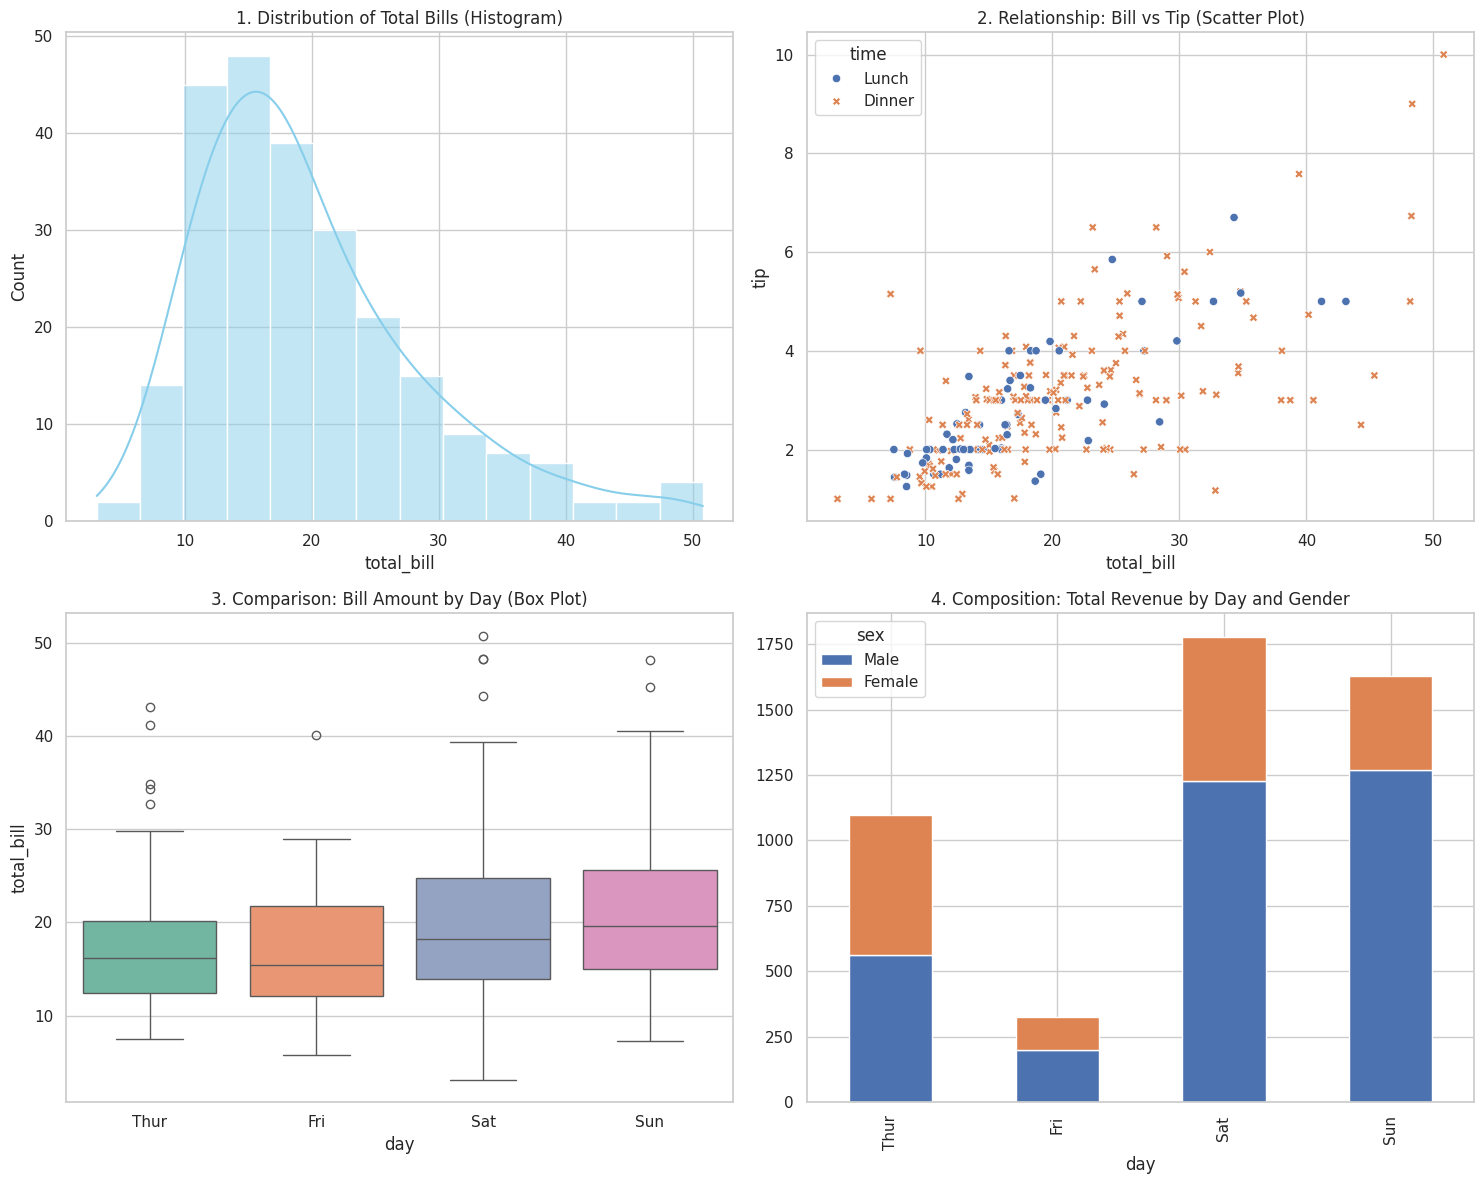

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load an inbuilt dataset representing restaurant transactions
df = sns.load_dataset('tips')

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. DISTRIBUTION: Histogram with KDE
# Purpose: Shows the spread and skewness of a single numerical variable.
sns.histplot(df['total_bill'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('1. Distribution of Total Bills (Histogram)')

# 2. RELATIONSHIP: Scatter Plot
# Purpose: Shows how two numerical variables correlate.
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', style='time', ax=axes[0,1])
axes[0,1].set_title('2. Relationship: Bill vs Tip (Scatter Plot)')

# 3. COMPARISON: Box Plot
# Purpose: Compares numerical distributions across categories (e.g., Days).
sns.boxplot(data=df, x='day', y='total_bill', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('3. Comparison: Bill Amount by Day (Box Plot)')

# 4. COMPOSITION: Stacked Bar Chart (Via Pandas)
# Purpose: Shows how a total is broken down into parts.
df_pivot = df.groupby(['day', 'sex'])['total_bill'].sum().unstack()
df_pivot.plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title('4. Composition: Total Revenue by Day and Gender')

plt.tight_layout()
plt.show()

Use SMOTE technique to generate synthetic data. (to solve the problem of class imbalance)\\

Original dataset shape: Counter({np.int64(0): 901, np.int64(1): 99})
Resampled dataset shape: Counter({np.int64(0): 901, np.int64(1): 901})


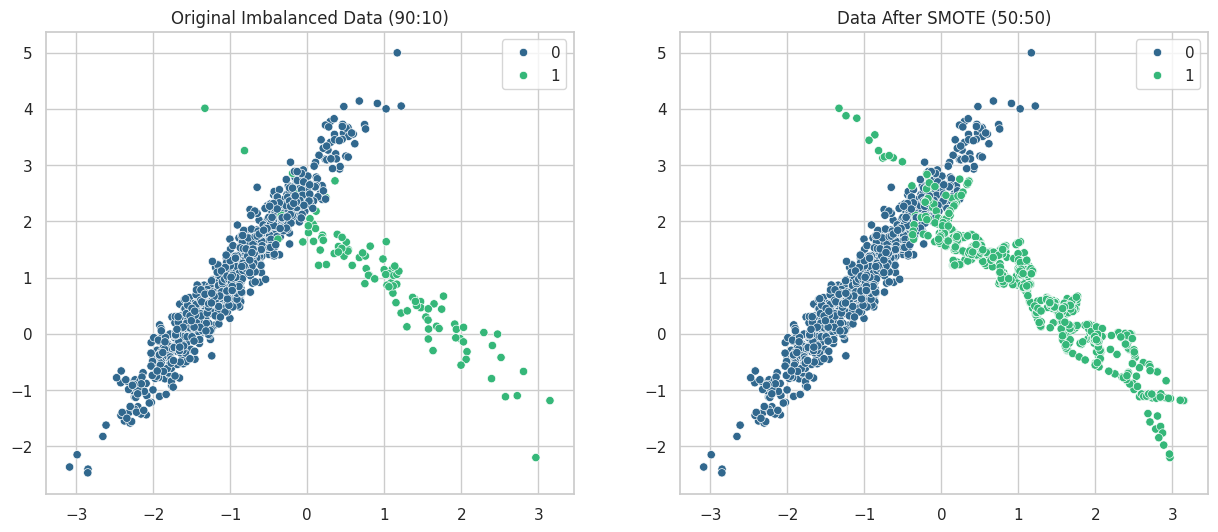

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE
from collections import Counter

# --- 1. DATASET GENERATION ---
# Creating a synthetic dataset with a 90:10 imbalance ratio
# 1000 samples, 2 features for easy visualization
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.90],
                           flip_y=0, random_state=42)

print(f"Original dataset shape: {Counter(y)}")

# --- 2. APPLYING SMOTE ---
# SMOTE works by picking a point, finding its k-nearest neighbors,
# and creating new points along the lines connecting them.
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(f"Resampled dataset shape: {Counter(y_res)}")

# --- 3. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Original Data
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, ax=ax1, palette='viridis')
ax1.set_title("Original Imbalanced Data (90:10)")

# Plot SMOTE Data
sns.scatterplot(x=X_res[:, 0], y=X_res[:, 1], hue=y_res, ax=ax2, palette='viridis')
ax2.set_title("Data After SMOTE (50:50)")

plt.show()

Implement time series forecasting.

--- Dataset Structure ---
           ds    y
0  1949-01-01  112
1  1949-02-01  118
2  1949-03-01  132
3  1949-04-01  129
4  1949-05-01  121


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


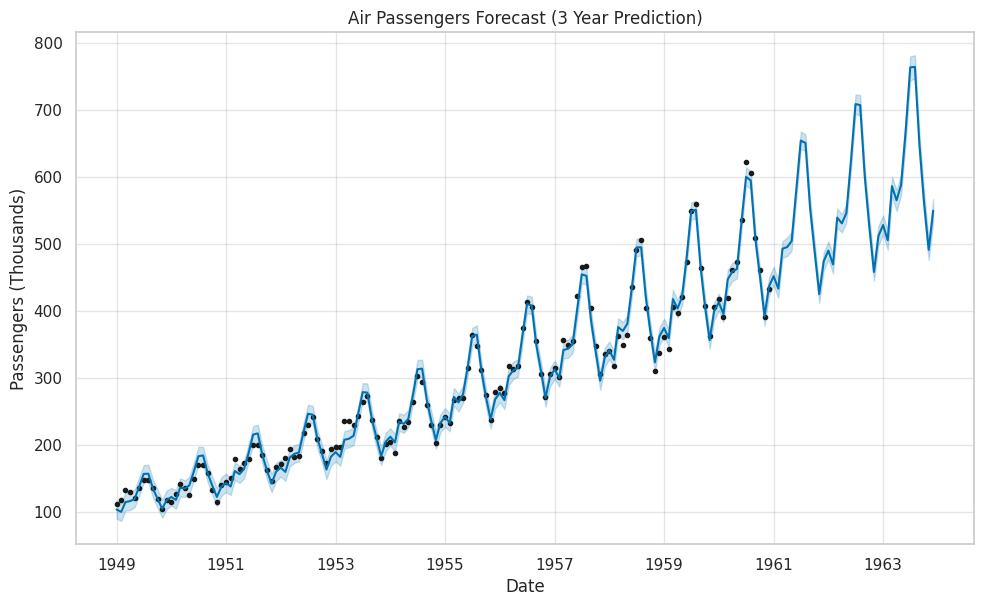

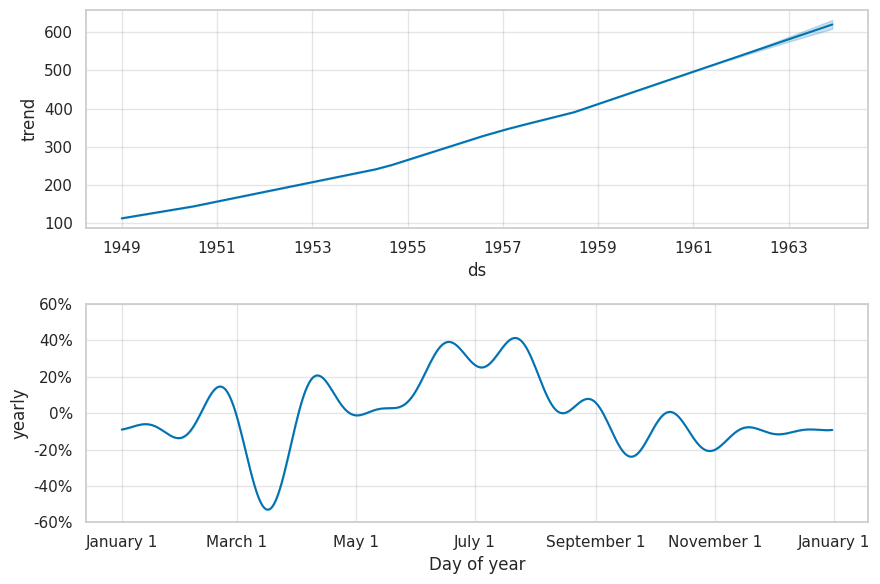

In [6]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Load the inbuilt Air Passengers dataset
# This dataset contains the monthly number of passengers (in thousands)
url = 'https://raw.githubusercontent.com/facebook/prophet/main/examples/example_air_passengers.csv'
df = pd.read_csv(url)

# 2. Data Preparation
# Prophet requires two specific column names:
# 'ds' (datestamp) and 'y' (the numeric value to forecast)
print("--- Dataset Structure ---")
print(df.head())

# 3. Initialize and Train the Model
# We set seasonality to 'multiplicative' because the passenger
# growth variation increases over time.
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)

# 4. Create a Future Dataframe
# Here we ask the model to predict the next 36 months (3 years)
future = model.make_future_dataframe(periods=36, freq='MS')

# 5. Generate Forecast
forecast = model.predict(future)

# 6. Visualization
# The Black dots are actual data, the Blue line is the forecast,
# and the light blue shaded area is the uncertainty interval.
fig1 = model.plot(forecast)
plt.title("Air Passengers Forecast (3 Year Prediction)")
plt.xlabel("Date")
plt.ylabel("Passengers (Thousands)")
plt.show()

# 7. Decomposing Components
# This shows the overall trend, weekly seasonality, and yearly seasonality.
fig2 = model.plot_components(forecast)
plt.show()

Implement K Fold Cross Validation on any data set.

In [7]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. Load the inbuilt dataset
# This dataset contains features computed from a digitized image of a fine needle
# aspirate (FNA) of a breast mass. It targets: Malignant or Benign.
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Initialize the Model
# We'll use a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Setup K-Fold Cross Validation
# n_splits=5 means the data is divided into 5 "folds"
# shuffle=True ensures the data is mixed before splitting
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Execute Cross-Validation
# We calculate 'accuracy' for each of the 5 runs
scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

# 5. Output Results
print("--- K-Fold Cross Validation Results (K=5) ---")
for i, score in enumerate(scores, 1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print("-" * 30)
print(f"Mean Accuracy: {np.mean(scores):.4f}")
print(f"Standard Deviation: {np.std(scores):.4f}")

--- K-Fold Cross Validation Results (K=5) ---
Fold 1 Accuracy: 0.9561
Fold 2 Accuracy: 0.9649
Fold 3 Accuracy: 0.9386
Fold 4 Accuracy: 0.9649
Fold 5 Accuracy: 0.9646
------------------------------
Mean Accuracy: 0.9578
Standard Deviation: 0.0102
